In [1]:

%load_ext autoreload
%autoreload 2
import sys

from rdkit import Chem

sys.path.append('src')


In [2]:
from src import MoleculeRenderer, DataLoader


def draw_mol(mol, title="", highlight_atoms=None, highlight_bonds=None, display_props=None):
    mr = MoleculeRenderer()
    display(mr.render_2d(mol, title, highlight_atoms, highlight_bonds, display_props))


✓ FragmentManager инициализирован

1. Тест добавления фрагментов:
Созданные молекулы для тестирования:


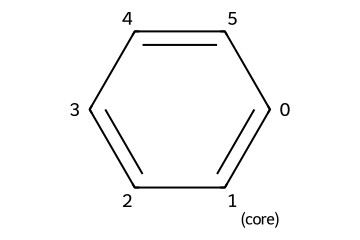

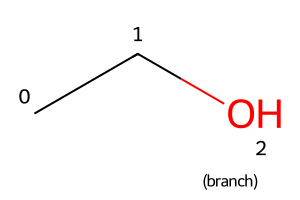

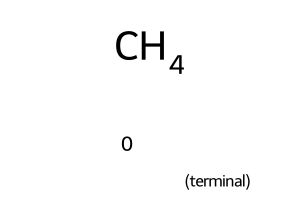

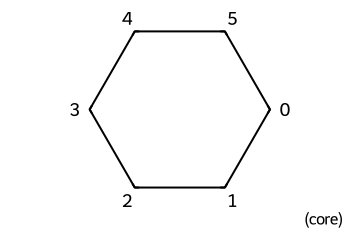

✓ Добавлен фрагмент: core_0


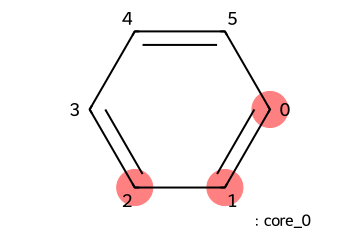

✓ Добавлен фрагмент: branch_1


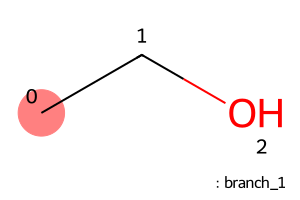

✓ Добавлен фрагмент с кастомным именем: methane_custom


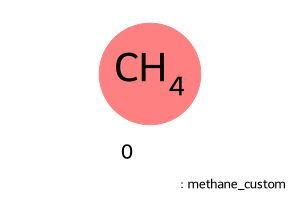

✓ Добавлен фрагмент: core_3


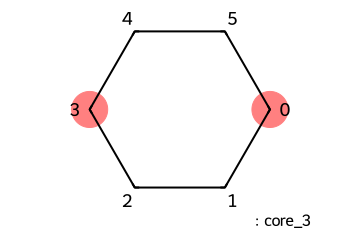


2. Тест получения фрагментов:
✓ Получен фрагмент core_0: c1ccccc1

Визуализация всех фрагментов в библиотеке:


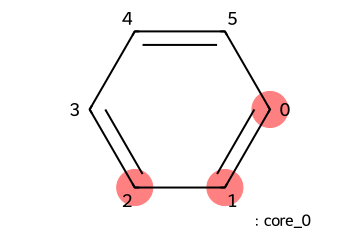

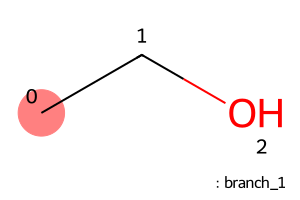

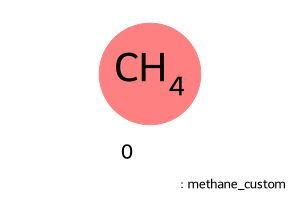

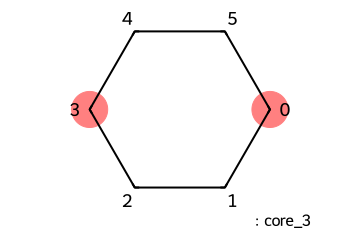


3. Тест списков и фильтрации:
✓ Все фрагменты: ['core_0', 'branch_1', 'methane_custom', 'core_3']
✓ Core фрагменты: ['core_0', 'core_3']

Core фрагменты:


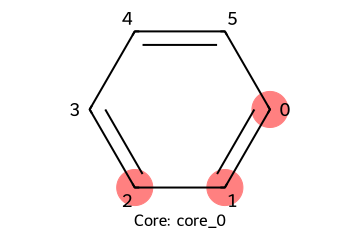

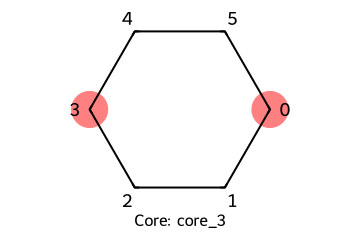

✓ Branch фрагменты: ['branch_1']


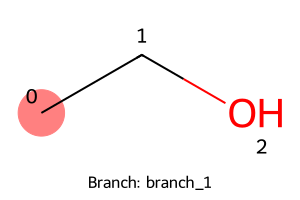


4. Тест статистики:
✓ Общая статистика:
  - Всего фрагментов: 4
  - Фрагментов по типам: {'core': 2, 'branch': 1, 'terminal': 1}
  - Всего атомов: 16
  - Фрагментов с соединениями: 4

Распределение фрагментов по типам:
  core: 2 фрагментов
  branch: 1 фрагментов
  terminal: 1 фрагментов

5. Тест обновления фрагментов:
До обновления:


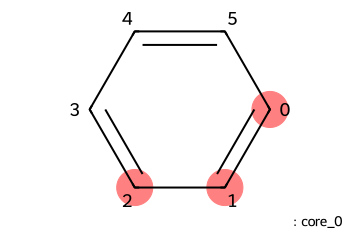

✓ Обновление фрагмента: True
После обновления:


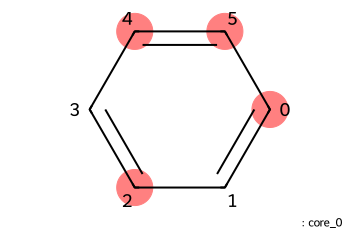


6. Тест сохранения и загрузки:
Fragment library saved to: C:\Users\apida\AppData\Local\Temp\tmpdh_dl20q.json
✓ Сохранение библиотеки: True
Библиотека перед сохранением:


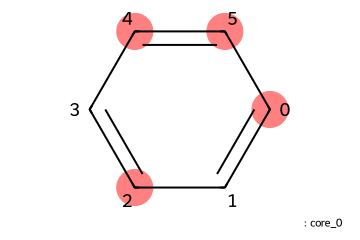

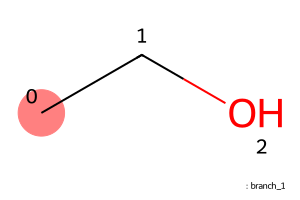

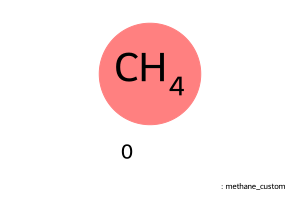

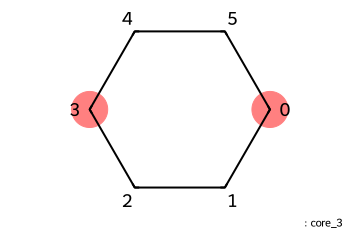

Fragment library loaded from: C:\Users\apida\AppData\Local\Temp\tmpdh_dl20q.json
Fragments loaded: 4
✓ Загрузка библиотеки: True
Библиотека после загрузки:


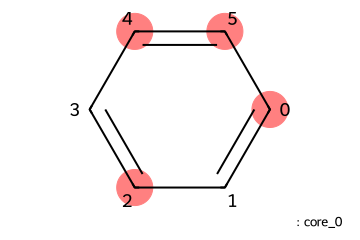

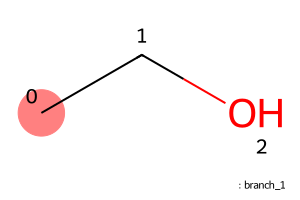

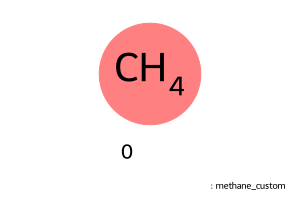

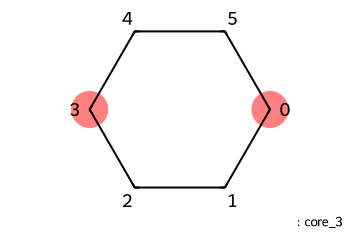

✓ Загруженные фрагменты: ['core_0', 'branch_1', 'methane_custom', 'core_3']
✓ Совпадение данных: True

7. Тест удаления фрагментов:
Перед удалением:


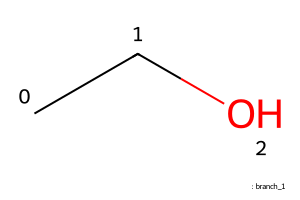

✓ Удаление фрагмента branch_1: True
✓ Фрагменты после удаления: ['core_0', 'methane_custom', 'core_3']
Оставшиеся фрагменты после удаления:


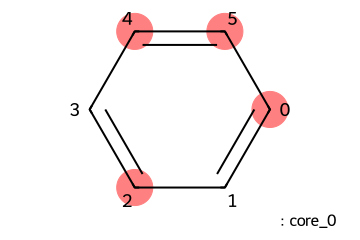

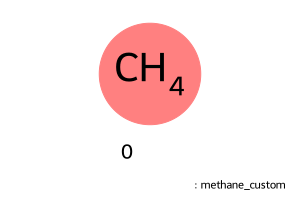

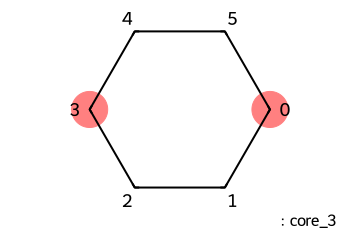


8. Тест очистки библиотеки:
Библиотека перед очисткой:


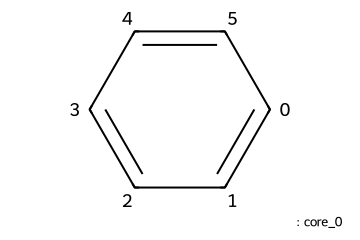

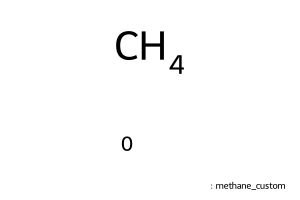

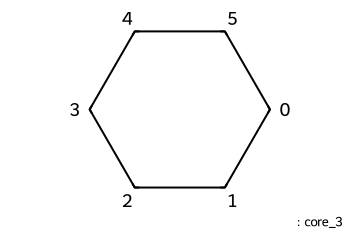

Library cleared. Removed 3 fragments.
✓ Очищено фрагментов: 3
✓ Библиотека пуста: True

9. Тест обработки ошибок:
✓ Корректная обработка None молекулы: Fragment molecule cannot be None

=== Все тесты завершены ===


In [3]:
from src import FragmentManager, DataSaver
import tempfile
import os


def test_fragment_manager_with_visualization(need_clean):
    """Комплексное тестирование FragmentManager с визуализацией"""

    # Инициализация менеджера
    fm = FragmentManager()
    print("✓ FragmentManager инициализирован")

    # Тест 1: Добавление фрагментов с визуализацией
    print("\n1. Тест добавления фрагментов:")

    # Создаем тестовые молекулы
    benzene = Chem.MolFromSmiles('c1ccccc1')
    ethanol = Chem.MolFromSmiles('CCO')
    methane = Chem.MolFromSmiles('C')
    cyclohexane = Chem.MolFromSmiles('C1CCCCC1')

    print("Созданные молекулы для тестирования:")
    draw_mol(benzene, "Бензол (core)")
    draw_mol(ethanol, "Этанол (branch)")
    draw_mol(methane, "Метан (terminal)")
    draw_mol(cyclohexane, "Циклогексан (core)")

    # Добавляем фрагменты с автоматическими именами
    frag1_id = fm.add_fragment(
        fragment=benzene,
        fragment_type="core",
        connection_atoms=[0, 1, 2],
        replacement_groups=['H', 'OH']
    )
    print(f"✓ Добавлен фрагмент: {frag1_id}")

    frag1_data = fm.get_fragment(frag1_id)
    draw_mol(frag1_data['molecule'], f"Фрагмент: {frag1_id}",
             highlight_atoms=[0, 1, 2],
             display_props={'Тип': 'core', 'Атомы соединения': '0,1,2'})

    frag2_id = fm.add_fragment(
        fragment=ethanol,
        fragment_type="branch",
        connection_atoms=[0],
        replacement_groups=['H']
    )
    print(f"✓ Добавлен фрагмент: {frag2_id}")

    frag2_data = fm.get_fragment(frag2_id)
    draw_mol(frag2_data['molecule'], f"Фрагмент: {frag2_id}",
             highlight_atoms=[0],
             display_props={'Тип': 'branch', 'Атом соединения': '0'})

    # Добавляем фрагмент с кастомным именем
    frag3_id = fm.add_fragment(
        fragment=methane,
        name="methane_custom",
        fragment_type="terminal",
        connection_atoms=[0],
        replacement_groups=['Cl', 'Br']
    )
    print(f"✓ Добавлен фрагмент с кастомным именем: {frag3_id}")

    frag3_data = fm.get_fragment(frag3_id)
    draw_mol(frag3_data['molecule'], f"Фрагмент: {frag3_id}",
             highlight_atoms=[0],
             display_props={'Тип': 'terminal', 'Замещения': 'Cl, Br'})

    # Добавляем еще один фрагмент для демонстрации
    frag4_id = fm.add_fragment(
        fragment=cyclohexane,
        fragment_type="core",
        connection_atoms=[0, 3],
        replacement_groups=['H', 'CH3']
    )
    print(f"✓ Добавлен фрагмент: {frag4_id}")

    frag4_data = fm.get_fragment(frag4_id)
    draw_mol(frag4_data['molecule'], f"Фрагмент: {frag4_id}",
             highlight_atoms=[0, 3],
             display_props={'Тип': 'core', 'Атомы соединения': '0,3'})

    # Тест 2: Получение фрагментов
    print("\n2. Тест получения фрагментов:")

    # Получение по ID
    frag1 = fm.get_fragment(frag1_id)
    print(f"✓ Получен фрагмент {frag1_id}: {frag1['smiles']}")

    # Визуализируем все фрагменты из библиотеки
    print("\nВизуализация всех фрагментов в библиотеке:")
    all_fragments = fm.list_fragments()
    for frag_id in all_fragments:
        frag_data = fm.get_fragment(frag_id)
        draw_mol(frag_data['molecule'], f"Фрагмент: {frag_id}",
                highlight_atoms=frag_data['connection_points'],
                display_props={
                    'Тип': frag_data['type'],
                    'Атомы соединения': str(frag_data['connection_points']),
                    'Замещения': str(frag_data['replacement_groups']),
                    'Всего атомов': frag_data['num_atoms']
                })

    # Тест 3: Список фрагментов
    print("\n3. Тест списков и фильтрации:")

    print(f"✓ Все фрагменты: {all_fragments}")

    # Визуализируем фрагменты по типам
    core_fragments = fm.get_fragment_by_type("core")
    print(f"✓ Core фрагменты: {list(core_fragments.keys())}")

    print("\nCore фрагменты:")
    for frag_id, frag_data in core_fragments.items():
        draw_mol(frag_data['molecule'], f"Core: {frag_id}",
                highlight_atoms=frag_data['connection_points'])

    branch_fragments = fm.get_fragment_by_type("branch")
    print(f"✓ Branch фрагменты: {list(branch_fragments.keys())}")

    if branch_fragments:
        for frag_id, frag_data in branch_fragments.items():
            draw_mol(frag_data['molecule'], f"Branch: {frag_id}",
                    highlight_atoms=frag_data['connection_points'])

    # Тест 4: Статистика
    print("\n4. Тест статистики:")

    stats = fm.get_fragment_statistics()
    print(f"✓ Общая статистика:")
    print(f"  - Всего фрагментов: {stats['total_fragments']}")
    print(f"  - Фрагментов по типам: {stats['fragments_by_type']}")
    print(f"  - Всего атомов: {stats['total_atoms']}")
    print(f"  - Фрагментов с соединениями: {stats['fragments_with_connections']}")

    # Визуализируем распределение по типам
    print("\nРаспределение фрагментов по типам:")
    for frag_type, count in stats['fragments_by_type'].items():
        print(f"  {frag_type}: {count} фрагментов")

    # Тест 5: Обновление фрагментов с визуализацией
    print("\n5. Тест обновления фрагментов:")

    print("До обновления:")
    frag1_before = fm.get_fragment(frag1_id)
    draw_mol(frag1_before['molecule'], f"До обновления: {frag1_id}",
             highlight_atoms=frag1_before['connection_points'],
             display_props={'connection_points': frag1_before['connection_points']})

    update_success = fm.update_fragment(
        frag1_id,
        type="modified_core",
        connection_points=[0, 2, 4, 5],  # Добавляем больше точек соединения
        replacement_groups=['H', 'CH3', 'NH2']
    )
    print(f"✓ Обновление фрагмента: {update_success}")

    print("После обновления:")
    updated_frag = fm.get_fragment(frag1_id)
    draw_mol(updated_frag['molecule'], f"После обновления: {frag1_id}",
             highlight_atoms=updated_frag['connection_points'],
             display_props={
                 'connection_points': updated_frag['connection_points'],
                 'type': updated_frag['type'],
                 'replacement_groups': updated_frag['replacement_groups']
             })

    # Тест 6: Сохранение и загрузка
    print("\n6. Тест сохранения и загрузки:")

    # Создаем временный файл
    with tempfile.NamedTemporaryFile(mode='w', suffix='.json', delete=False) as f:
        temp_filename = f.name

    try:
        # Сохраняем библиотеку
        save_success = DataSaver().save_fragment_library(fm, temp_filename)
        print(f"✓ Сохранение библиотеки: {save_success}")

        # Визуализируем текущее состояние перед сохранением
        print("Библиотека перед сохранением:")
        for frag_id in fm.list_fragments():
            frag_data = fm.get_fragment(frag_id)
            draw_mol(frag_data['molecule'], f"Перед сохранением: {frag_id}",
                    highlight_atoms=frag_data['connection_points'])

        # Создаем новый менеджер и загружаем данные
        fm2 = FragmentManager()
        load_success = DataLoader().load_fragment_library(temp_filename, fm2)
        print(f"✓ Загрузка библиотеки: {load_success}")

        # Визуализируем загруженные фрагменты
        print("Библиотека после загрузки:")
        loaded_fragments = fm2.list_fragments()
        for frag_id in loaded_fragments:
            frag_data = fm2.get_fragment(frag_id)
            draw_mol(frag_data['molecule'], f"После загрузки: {frag_id}",
                    highlight_atoms=frag_data['connection_points'],
                    display_props={'type': frag_data['type']})

        # Проверяем, что данные совпадают
        print(f"✓ Загруженные фрагменты: {loaded_fragments}")
        print(f"✓ Совпадение данных: {set(all_fragments) == set(loaded_fragments)}")

    finally:
        # Удаляем временный файл
        if os.path.exists(temp_filename):
            os.unlink(temp_filename)

    # Тест 7: Удаление фрагментов
    print("\n7. Тест удаления фрагментов:")

    print("Перед удалением:")
    frag_to_remove = fm.get_fragment(frag2_id)
    draw_mol(frag_to_remove['molecule'], f"Фрагмент для удаления: {frag2_id}")

    remove_success = fm.remove_fragment(frag2_id)
    print(f"✓ Удаление фрагмента {frag2_id}: {remove_success}")

    fragments_after_remove = fm.list_fragments()
    print(f"✓ Фрагменты после удаления: {fragments_after_remove}")

    # Визуализируем оставшиеся фрагменты
    print("Оставшиеся фрагменты после удаления:")
    for frag_id in fragments_after_remove:
        frag_data = fm.get_fragment(frag_id)
        draw_mol(frag_data['molecule'], f"Оставшийся: {frag_id}",
                highlight_atoms=frag_data['connection_points'])
    if need_clean:

        # Тест 8: Очистка библиотеки
        print("\n8. Тест очистки библиотеки:")

        print("Библиотека перед очисткой:")
        for frag_id in fm.list_fragments():
            frag_data = fm.get_fragment(frag_id)
            draw_mol(frag_data['molecule'], f"Перед очисткой: {frag_id}")

        cleared_count = fm.clear_library()
        print(f"✓ Очищено фрагментов: {cleared_count}")
        print(f"✓ Библиотека пуста: {len(fm.list_fragments()) == 0}")

    # Тест 9: Обработка ошибок
    print("\n9. Тест обработки ошибок:")

    # Попытка добавить None молекулу
    try:
        fm.add_fragment(None)
    except ValueError as e:
        print(f"✓ Корректная обработка None молекулы: {e}")

    print("\n=== Все тесты завершены ===")
    return fm

fragment_manager = test_fragment_manager_with_visualization(True)

Fragment library loaded from: dendrimer_fragments.json
Fragments loaded: 3


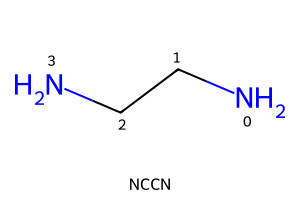

In [4]:
DataLoader().load_fragment_library("dendrimer_fragments.json",fragment_manager)

core_data = fragment_manager.fragments["NCCN_core"]
core_mol = core_data['molecule']
draw_mol(core_mol,display_props=["connection_type"])

In [5]:

from src.interfaces.fragment_data_manager import FragmentDataManager
from src.interfaces.fragment_builder import DendrimerFragmentBuilder
from src.core.fragment_manager import FragmentManager

# Тестирование модуля interfaces.fragment_builder.py

def test_fragment_builder():
    # Инициализация билдера
    builder = DendrimerFragmentBuilder()
    print("\nОтображение интерфейса:")
    builder.display_interface()
    return builder

# Запуск тестов
print("Запуск тестов DendrimerFragmentBuilder...")
test_builder = test_fragment_builder()

Запуск тестов DendrimerFragmentBuilder...

Отображение интерфейса:


HTML(value='<h3>Fragment List:</h3>')

Output()

=== Тестирование FragmentDataManager ===
=== Тестирование FragmentDataManager ===
✓ FragmentManager инициализирован

1. Тест добавления фрагментов:
Созданные молекулы для тестирования:


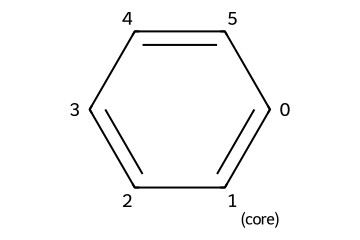

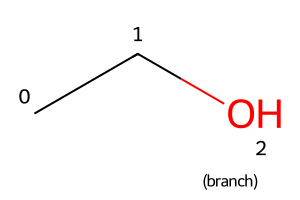

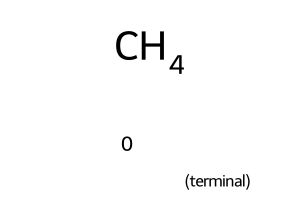

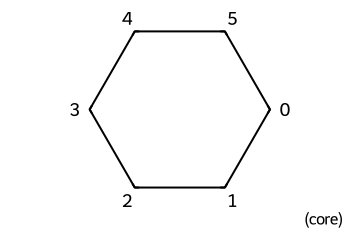

✓ Добавлен фрагмент: core_0


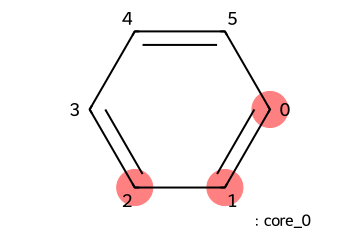

✓ Добавлен фрагмент: branch_1


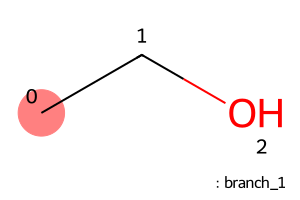

✓ Добавлен фрагмент с кастомным именем: methane_custom


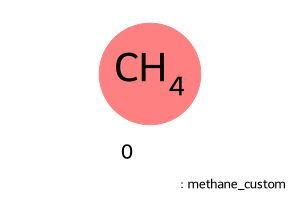

✓ Добавлен фрагмент: core_3


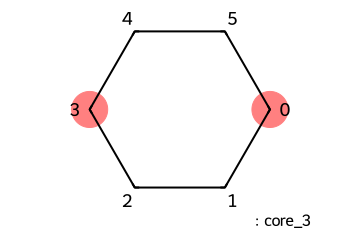


2. Тест получения фрагментов:
✓ Получен фрагмент core_0: c1ccccc1

Визуализация всех фрагментов в библиотеке:


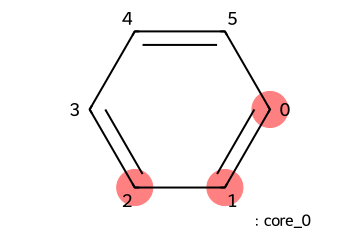

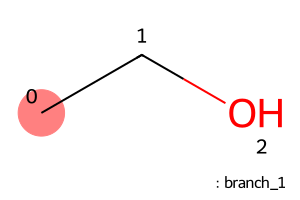

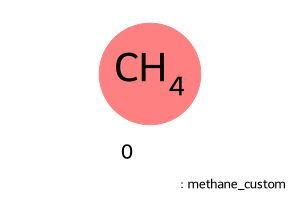

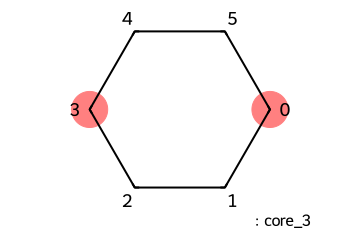


3. Тест списков и фильтрации:
✓ Все фрагменты: ['core_0', 'branch_1', 'methane_custom', 'core_3']
✓ Core фрагменты: ['core_0', 'core_3']

Core фрагменты:


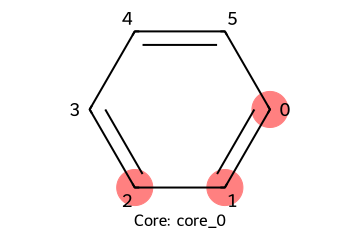

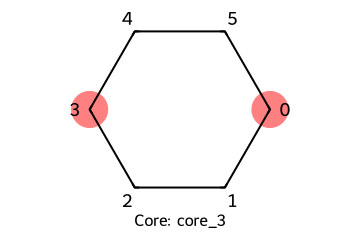

✓ Branch фрагменты: ['branch_1']


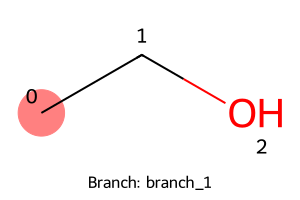


4. Тест статистики:
✓ Общая статистика:
  - Всего фрагментов: 4
  - Фрагментов по типам: {'core': 2, 'branch': 1, 'terminal': 1}
  - Всего атомов: 16
  - Фрагментов с соединениями: 4

Распределение фрагментов по типам:
  core: 2 фрагментов
  branch: 1 фрагментов
  terminal: 1 фрагментов

5. Тест обновления фрагментов:
До обновления:


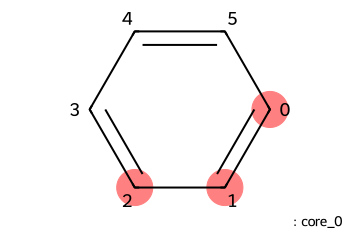

✓ Обновление фрагмента: True
После обновления:


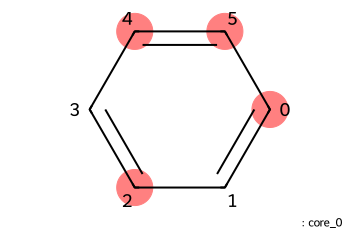


6. Тест сохранения и загрузки:
Fragment library saved to: C:\Users\apida\AppData\Local\Temp\tmp32ebvcmp.json
✓ Сохранение библиотеки: True
Библиотека перед сохранением:


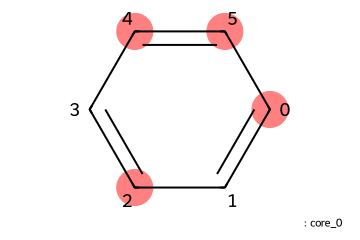

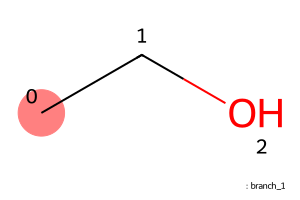

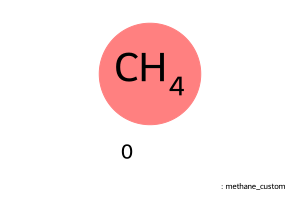

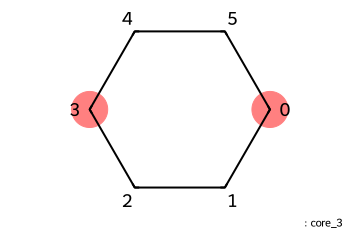

Fragment library loaded from: C:\Users\apida\AppData\Local\Temp\tmp32ebvcmp.json
Fragments loaded: 4
✓ Загрузка библиотеки: True
Библиотека после загрузки:


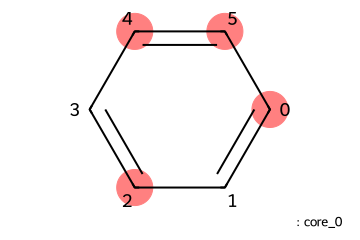

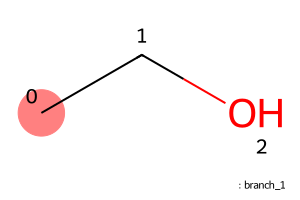

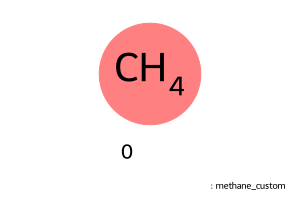

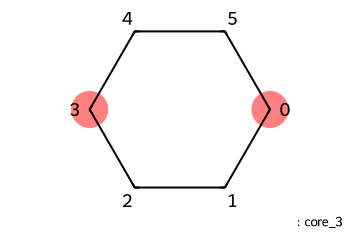

✓ Загруженные фрагменты: ['core_0', 'branch_1', 'methane_custom', 'core_3']
✓ Совпадение данных: True

7. Тест удаления фрагментов:
Перед удалением:


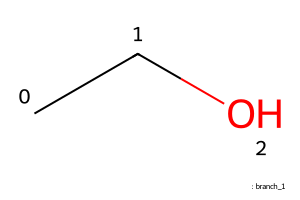

✓ Удаление фрагмента branch_1: True
✓ Фрагменты после удаления: ['core_0', 'methane_custom', 'core_3']
Оставшиеся фрагменты после удаления:


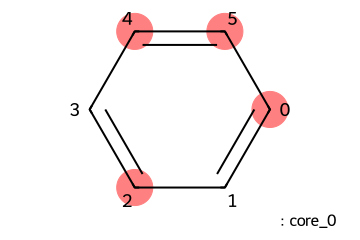

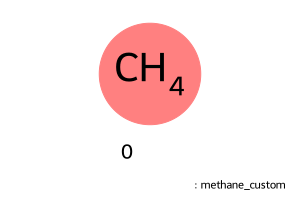

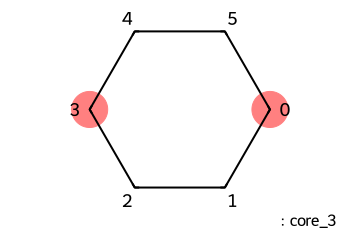


9. Тест обработки ошибок:
✓ Корректная обработка None молекулы: Fragment molecule cannot be None

=== Все тесты завершены ===


In [6]:

# Тестирование модуля interfaces.fragment_data_manager.py
print("=== Тестирование FragmentDataManager ===")

from src.interfaces.fragment_data_manager import FragmentDataManager
from src.interfaces.fragment_builder import DendrimerFragmentBuilder
from src.core.fragment_manager import FragmentManager

# Тестирование модуля interfaces.fragment_data_manager.py
print("=== Тестирование FragmentDataManager ===")

import tempfile
import os
import json
#
# def draw_mol(mol, title="", highlight_atoms=None, highlight_bonds=None, display_props=None):
#     pass

def real_workflow_example():
    fm = test_fragment_manager_with_visualization(False)
    builder = DendrimerFragmentBuilder()
    data_manager = FragmentDataManager(builder, fm)
    return fm, builder, data_manager


# Запускаем пример
fm_final, builder_final, dm_final = real_workflow_example()

In [7]:
builder_final.display_interface()
dm_final.display_interface()

HTML(value='<h3>Fragment List:</h3>')

Output()

HTML(value='<h3>Data Management</h3>')

HTML(value='<strong>Operation status:</strong>')

Output(layout=Layout(border_bottom='1px solid gray', border_left='1px solid gray', border_right='1px solid gra…

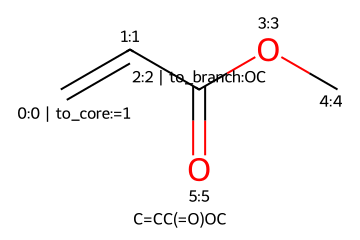

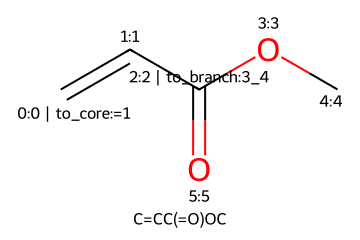

In [8]:
def freeze_original_index(mol):
    for i, atom in enumerate(mol.GetAtoms()):
        atom.SetProp("original_index", str(i))  # Зафриженный исходный индекс


def create_methyl_acrylate_with_metadata_smiles():
    return create_methyl_acrylate_with_metadata("OC")


def create_methyl_acrylate_with_metadata_indexes():
    return create_methyl_acrylate_with_metadata("3_4")

methyl_acrylate_smiles = "C=CC(OC)=O"
def create_methyl_acrylate_with_metadata(tail):
    """Создаем молекулу метилакрилата с метаданными о точках соединения"""
    smiles = methyl_acrylate_smiles
    mol = Chem.MolFromSmiles(smiles)

    # connection_atoms: [0, 2]
    # Первый атом (0) - для соединения с основой
    # Второй атом (2) - для присоединения продолжения ветви
    connection_atoms = [0, 2]
    replacement_groups = ["=1", tail]

    freeze_original_index(mol)

    for i, atom_idx in enumerate(connection_atoms):
        methyl_acrylate_atom = mol.GetAtomWithIdx(atom_idx)
        methyl_acrylate_atom.SetProp("is_connection", "true")
        methyl_acrylate_atom.SetProp("replacement_group", replacement_groups[i])

        # Размечаем тип точки соединения
        if i == 0:
            methyl_acrylate_atom.SetProp("connection_type", "to_core")  # Для соединения с основой
        else:
            methyl_acrylate_atom.SetProp("connection_type", "to_branch")  # Для присоединения продолжения

    return mol


methyl_acrylate = create_methyl_acrylate_with_metadata_smiles()
draw_mol(methyl_acrylate, display_props=["original_index", "connection_type", "replacement_group"])

methyl_acrylate_i = create_methyl_acrylate_with_metadata_indexes()
draw_mol(methyl_acrylate_i, display_props=["original_index", "connection_type", "replacement_group"])

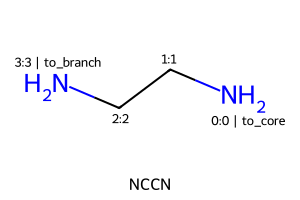

In [9]:

def create_ethylenediamine_with_metadata():
    """Создаем молекулу этилендиамина с метаданными о точках соединения"""
    smiles = "NCCN"
    ethylenediamine_mol = Chem.MolFromSmiles(smiles)

    freeze_original_index(ethylenediamine_mol)
    # connection_atoms: [0, 0, 3]
    # Первый атом (0) - для соединения с основой
    # Остальные (0, 3) - для присоединения продолжения ветви
    connection_atoms = [0, 3]
    replacement_groups = ["H", "H"]

    for i, atom_idx in enumerate(connection_atoms):
        ethylenediamine_atom = ethylenediamine_mol.GetAtomWithIdx(atom_idx)
        ethylenediamine_atom.SetProp("is_connection", "true")
        ethylenediamine_atom.SetProp("replacement_group", replacement_groups[i])

        if i == 0:
            ethylenediamine_atom.SetProp("connection_type", "to_core")  # К основе
        else:
            ethylenediamine_atom.SetProp("connection_type", "to_branch")  # К продолжению ветви

    return ethylenediamine_mol


ethylenediamine = create_ethylenediamine_with_metadata()
draw_mol(ethylenediamine, display_props=["original_index", "connection_type"])

Running FormatConverters tests...

Testing JSON to metadata molecule conversion...


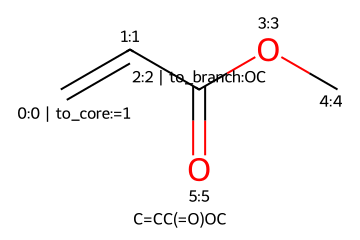

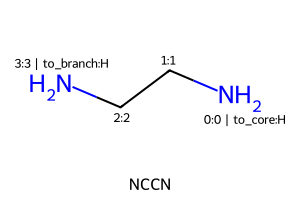

✓ JSON to metadata molecule conversion test passed
Testing metadata molecule to JSON conversion...
✓ Metadata molecule to JSON conversion test passed
Testing round-trip conversion...


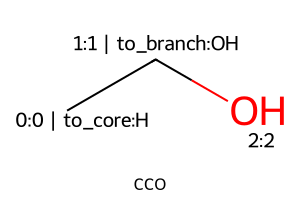

✓ Round-trip conversion test passed

🎉 All tests passed successfully!


In [10]:

from rdkit import Chem
from src.io.format_converters import FormatConverters

# Test data matching the manual creation methods
methyl_acrylate_json = {
    "name": "Methyl acrylate",
    "smiles": "C=CC(OC)=O",
    "connection_atoms": [0, 2],
    "replacement_groups": ["=1", "OC"],
    "num_atoms": 6
}

ethylenediamine_json = {
    "name": "Ethylenediamine",
    "smiles": "NCCN",
    "connection_atoms": [0, 3],
    "replacement_groups": ["H", "H"],
    "num_atoms": 4
}


def _validate_connection_properties(mol, expected_connection_atoms, expected_replacement_groups):
    """Validate that molecule has correct connection properties."""
    connection_atoms_found = []
    replacement_groups_found = []
    draw_mol(mol,display_props=["original_index", "connection_type", "replacement_group"])

    for atom in mol.GetAtoms():
        if atom.HasProp("is_connection") and atom.GetProp("is_connection") == "true":
            connection_atoms_found.append(atom.GetIdx())
            replacement_groups_found.append(atom.GetProp("replacement_group"))

            # Validate connection type
            if atom.GetIdx() == expected_connection_atoms[0]:
                assert atom.GetProp(
                    "connection_type") == "to_core", f"Expected 'to_core' for atom {atom.GetIdx()}, got '{atom.GetProp('connection_type')}'"
            else:
                assert atom.GetProp(
                    "connection_type") == "to_branch", f"Expected 'to_branch' for atom {atom.GetIdx()}, got '{atom.GetProp('connection_type')}'"

    assert connection_atoms_found == expected_connection_atoms, f"Connection atoms mismatch: expected {expected_connection_atoms}, got {connection_atoms_found}"
    assert replacement_groups_found == expected_replacement_groups, f"Replacement groups mismatch: expected {expected_replacement_groups}, got {replacement_groups_found}"


def _validate_json_structure(json_data, expected_connections, expected_replacements):
    """Validate JSON structure and content."""
    assert "smiles" in json_data, "Missing 'smiles' in JSON"
    assert "connection_atoms" in json_data, "Missing 'connection_atoms' in JSON"
    assert "replacement_groups" in json_data, "Missing 'replacement_groups' in JSON"
    assert "num_atoms" in json_data, "Missing 'num_atoms' in JSON"

    # SMILES может быть канонизирован, поэтому проверяем что молекулы эквивалентны
    mol_from_smiles = Chem.MolFromSmiles(json_data["smiles"])
    assert mol_from_smiles is not None, f"Invalid SMILES: {json_data['smiles']}"

    assert json_data[
               "connection_atoms"] == expected_connections, f"Connection atoms mismatch: expected {expected_connections}, got {json_data['connection_atoms']}"
    assert json_data[
               "replacement_groups"] == expected_replacements, f"Replacement groups mismatch: expected {expected_replacements}, got {json_data['replacement_groups']}"


def test_json_to_metadata_mol_conversion():
    """Test conversion from JSON to molecule with metadata."""
    print("Testing JSON to metadata molecule conversion...")

    # Convert using FormatConverters
    methyl_acrylate_mol = FormatConverters.json_to_metadata_mol(methyl_acrylate_json)
    ethylenediamine_mol = FormatConverters.json_to_metadata_mol(ethylenediamine_json)

    # Test methyl acrylate properties
    _validate_connection_properties(methyl_acrylate_mol, [0, 2], ["=1", "OC"])

    # Test ethylenediamine properties
    _validate_connection_properties(ethylenediamine_mol, [0, 3], ["H", "H"])

    print("✓ JSON to metadata molecule conversion test passed")


def test_metadata_mol_to_json_conversion():
    """Test conversion from molecule with metadata back to JSON."""
    print("Testing metadata molecule to JSON conversion...")

    # Create molecules using manual methods
    methyl_acrylate_mol = create_methyl_acrylate_with_metadata("OC")
    ethylenediamine_mol = create_ethylenediamine_with_metadata()

    # Convert back to JSON
    methyl_acrylate_json_result = FormatConverters.metadata_mol_to_json(methyl_acrylate_mol)
    ethylenediamine_json_result = FormatConverters.metadata_mol_to_json(ethylenediamine_mol)

    # Validate JSON structure and content (без проверки точного SMILES)
    _validate_json_structure(methyl_acrylate_json_result, [0, 2], ["=1", "OC"])
    _validate_json_structure(ethylenediamine_json_result, [0, 3], ["H", "H"])

    print("✓ Metadata molecule to JSON conversion test passed")


def test_round_trip_conversion():
    """Test complete round-trip conversion: JSON → Mol → JSON."""
    print("Testing round-trip conversion...")

    original_json = {
        "name": "Test Fragment",
        "smiles": "CCO",
        "connection_atoms": [0, 1],
        "replacement_groups": ["H", "OH"],
        "num_atoms": 3
    }

    # Convert to molecule and back
    mol = FormatConverters.json_to_metadata_mol(original_json)
    round_trip_json = FormatConverters.metadata_mol_to_json(mol)
    draw_mol(mol,display_props=["original_index", "connection_type", "replacement_group"])
    # Compare key properties (SMILES может отличаться из-за канонизации)
    # Проверяем что молекулы химически эквивалентны
    original_mol = Chem.MolFromSmiles(original_json["smiles"])
    round_trip_mol = Chem.MolFromSmiles(round_trip_json["smiles"])

    assert Chem.MolToInchi(original_mol) == Chem.MolToInchi(
        round_trip_mol), "Molecules are not equivalent in round-trip"
    assert original_json["connection_atoms"] == round_trip_json[
        "connection_atoms"], f"Connection atoms mismatch in round-trip: {original_json['connection_atoms']} != {round_trip_json['connection_atoms']}"
    assert original_json["replacement_groups"] == round_trip_json[
        "replacement_groups"], f"Replacement groups mismatch in round-trip: {original_json['replacement_groups']} != {round_trip_json['replacement_groups']}"

    print("✓ Round-trip conversion test passed")


# Run all tests
print("Running FormatConverters tests...\n")

try:
    test_json_to_metadata_mol_conversion()
    test_metadata_mol_to_json_conversion()
    test_round_trip_conversion()
    print("\n🎉 All tests passed successfully!")

except Exception as e:
    raise RuntimeError(f"❌ FormatConverter tests failed: {str(e)}")